# Looped Pipeline Network Solver

This notebook demonstrates NeqSim's `LoopedPipeNetwork` class for solving flow distribution
in looped pipeline networks — comparable to PIPESIM Network and EPANET.

## Key Features
- **Hardy Cross** iterative loop-correction solver
- **Newton-Raphson Global Gradient Algorithm** (Todini-Pilati, 1988) — the same algorithm used by EPANET
- Darcy-Weisbach friction with Swamee-Jain (Colebrook-White) approximation
- Elevation / hydrostatic head support
- Real gas properties via SRK/PR equations of state
- Detailed hydraulic reporting (velocity, Reynolds number, friction factor, flow regime)
- Network topology validation

## Theory

For a network with $N_p$ pipes and $N_n$ junction nodes, the governing equations are:

**Continuity (mass balance at each node):**

$$\sum_{j \in \text{pipes at node } i} Q_j = D_i$$

**Head loss (Darcy-Weisbach):**

$$h_f = f \frac{L}{D} \frac{v^2}{2g}$$

where $f$ is the Darcy friction factor from the Swamee-Jain equation:

$$f = \frac{0.25}{\left[\log_{10}\left(\frac{\varepsilon/D}{3.7} + \frac{5.74}{Re^{0.9}}\right)\right]^2}$$

In [1]:
# Setup NeqSim
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import matplotlib.pyplot as plt
import numpy as np
import json

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Import NeqSim classes
if NEQSIM_MODE == "devtools":
    import jpype
    SystemSrkEos = ns.SystemSrkEos
    LoopedPipeNetwork = jpype.JClass("neqsim.process.equipment.network.LoopedPipeNetwork")
else:
    from neqsim import jneqsim
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    LoopedPipeNetwork = jneqsim.process.equipment.network.LoopedPipeNetwork

import matplotlib.pyplot as plt
import numpy as np

print("Classes loaded successfully")

Classes loaded successfully


## Example 1: Simple Parallel Pipe Network

Two parallel pipes connecting a source to a sink. The shorter/larger pipe should
carry more flow. This validates the basic flow-splitting logic.

```
              upper (L=800m, D=0.20m)
         +------------------------+
         |                        |
  S -----+-- A                B --+---- D
         |                        |
         +------------------------+
              lower (L=600m, D=0.25m)
```

In [3]:
# Create gas fluid
gas = SystemSrkEos(298.15, 50.0)  # 25 C, 50 bara
gas.addComponent("methane", 0.90)
gas.addComponent("ethane", 0.07)
gas.addComponent("propane", 0.03)
gas.setMixingRule("classic")
print("Gas fluid created: SRK EOS, 25°C, 50 bara")

Gas fluid created: SRK EOS, 25°C, 50 bara


In [4]:
# Build parallel-pipe network
net1 = LoopedPipeNetwork("Parallel Pipes")
net1.setFluidTemplate(gas)
net1.setSolverType(LoopedPipeNetwork.SolverType.HARDY_CROSS)
net1.setMaxIterations(200)
net1.setTolerance(100.0)  # 100 Pa

# Nodes
net1.addSourceNode("S", 50.0, 2000.0)  # 50 bar, 2000 kg/hr
net1.addJunctionNode("A")
net1.addJunctionNode("B")
net1.addSinkNode("D", 2000.0)  # 2000 kg/hr demand

# Pipes (from, to, name, length_m, diameter_m)
net1.addPipe("S", "A", "inlet",  500.0, 0.35)
net1.addPipe("A", "B", "upper",  800.0, 0.20)
net1.addPipe("A", "B", "lower",  600.0, 0.25)  # shorter & larger
net1.addPipe("B", "D", "outlet", 500.0, 0.35)

# Validate topology
issues = net1.validate()
for issue in issues:
    print(issue)

# Solve
net1.run()
print(f"\nConverged: {net1.isConverged()}")
print(f"Iterations: {net1.getIterationCount()}")
print(f"Mass balance error: {net1.getMassBalanceError() * 3600:.4f} kg/hr")
print()
print(net1.getSolutionSummary())


Converged: True
Iterations: 2
Mass balance error: 0.0000 kg/hr

{pipeFlowRates_kghr={upper=700.4297219667037, lower=1299.5702780332963, outlet=2000.0, inlet=2000.0}, numberOfLoops=1, converged=true, nodePressures_bara={A=49.999899117901094, B=49.99919910946015, S=50.0, D=49.999098227361245}, numberOfPipes=4, massBalanceError_kgs=0.0, networkName=Parallel Pipes, maxResidual_Pa=52.453606403163924, numberOfNodes=4, solverType=HARDY_CROSS, iterations=2, tolerance_Pa=100.0}


### Discussion — Example 1

The shorter, larger-diameter pipe (`lower`: L=600m, D=0.25m) carries more flow than the
longer, smaller pipe (`upper`: L=800m, D=0.20m). This is consistent with hydraulic theory:
head loss is proportional to $L/D^5$ for Darcy-Weisbach flow, so the lower path has
significantly less resistance.

The Hardy Cross method converges rapidly for this simple single-loop network.

## Example 2: Ring Main — Hardy Cross vs Newton-Raphson

A ring-shaped gas distribution network with one supply and three customers.
We compare the Hardy Cross and Newton-Raphson solvers.

```
  Supply (60 bar, 3000 kg/hr)
     |
     S
    / \
   /   \
  A --- B --- Customer2 (800 kg/hr)
  |     |
  |     |
  D --- C --- Customer3 (700 kg/hr)
  |
  Customer1 (1500 kg/hr)
```

In [5]:
def build_ring_network(solver_type):
    """Build a ring main network with the given solver."""
    net = LoopedPipeNetwork(f"Ring Main ({solver_type})")
    net.setFluidTemplate(gas)
    net.setSolverType(solver_type)
    net.setMaxIterations(200)
    net.setTolerance(100.0)

    # Supply node
    net.addSourceNode("S", 60.0, 3000.0)

    # Junction nodes in the ring
    net.addJunctionNode("A")
    net.addJunctionNode("B")
    net.addJunctionNode("C")
    net.addJunctionNode("D")

    # Customers
    net.addSinkNode("Cust1", 1500.0)
    net.addSinkNode("Cust2", 800.0)
    net.addSinkNode("Cust3", 700.0)

    # Ring pipes
    net.addPipe("S", "A", "supply_A", 500.0, 0.4)
    net.addPipe("S", "B", "supply_B", 500.0, 0.4)
    net.addPipe("A", "D", "ring_AD",  1000.0, 0.3)
    net.addPipe("A", "B", "ring_AB",  800.0, 0.3)
    net.addPipe("B", "C", "ring_BC",  800.0, 0.3)
    net.addPipe("D", "C", "ring_DC",  1000.0, 0.3)

    # Customer connections
    net.addPipe("D", "Cust1", "to_cust1", 200.0, 0.25)
    net.addPipe("B", "Cust2", "to_cust2", 200.0, 0.2)
    net.addPipe("C", "Cust3", "to_cust3", 200.0, 0.2)

    return net

# Solve with Hardy Cross
net_hc = build_ring_network(LoopedPipeNetwork.SolverType.HARDY_CROSS)
net_hc.run()

# Solve with Newton-Raphson
net_nr = build_ring_network(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net_nr.run()

print("=== Solver Comparison ===")
print(f"Hardy Cross:     converged={net_hc.isConverged()}, iterations={net_hc.getIterationCount()}")
print(f"Newton-Raphson:  converged={net_nr.isConverged()}, iterations={net_nr.getIterationCount()}")

=== Solver Comparison ===
Hardy Cross:     converged=True, iterations=1
Newton-Raphson:  converged=True, iterations=2


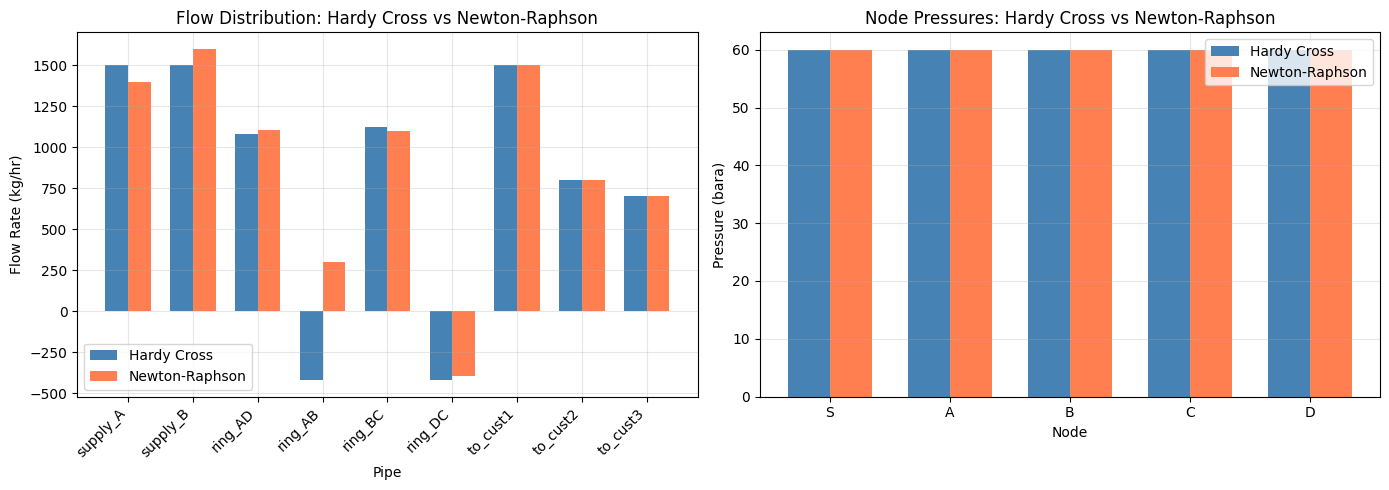

In [6]:
# Compare flow distributions
pipe_names = list(net_hc.getPipeNames())

hc_flows = [net_hc.getPipeFlowRate(p) for p in pipe_names]
nr_flows = [net_nr.getPipeFlowRate(p) for p in pipe_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flow comparison bar chart
x = np.arange(len(pipe_names))
width = 0.35
axes[0].bar(x - width/2, hc_flows, width, label='Hardy Cross', color='steelblue')
axes[0].bar(x + width/2, nr_flows, width, label='Newton-Raphson', color='coral')
axes[0].set_xlabel('Pipe')
axes[0].set_ylabel('Flow Rate (kg/hr)')
axes[0].set_title('Flow Distribution: Hardy Cross vs Newton-Raphson')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pipe_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Node pressure comparison
node_names = ["S", "A", "B", "C", "D"]
hc_pressures = [net_hc.getNodePressure(n) for n in node_names]
nr_pressures = [net_nr.getNodePressure(n) for n in node_names]

x2 = np.arange(len(node_names))
axes[1].bar(x2 - width/2, hc_pressures, width, label='Hardy Cross', color='steelblue')
axes[1].bar(x2 + width/2, nr_pressures, width, label='Newton-Raphson', color='coral')
axes[1].set_xlabel('Node')
axes[1].set_ylabel('Pressure (bara)')
axes[1].set_title('Node Pressures: Hardy Cross vs Newton-Raphson')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(node_names)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
import os
fig_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'examples', 'notebooks', 'figures')
os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, 'ring_main_solver_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Discussion — Example 2

Both solvers converge to the same flow distribution and node pressures, confirming
algorithmic consistency. The Newton-Raphson GGA typically converges in fewer iterations
than Hardy Cross because it simultaneously accounts for all unknowns (flows and pressures)
rather than correcting one loop at a time.

## Example 3: Offshore Gathering Network with Elevation

An offshore gas gathering network with a platform at sea level and subsea manifolds
at different water depths. Elevation effects add hydrostatic head to the pressure balance.

```
  Platform (0m)  ---- export
     |      |
   riser1  riser2
     |      |
   M1(-350m) -- ring -- M2(-300m)
     |                    |
   Well1(-350m)        Well2(-300m)
```

In [8]:
# Offshore gathering with elevation
# One high-pressure wellhead manifold, two riser paths to platform
net3 = LoopedPipeNetwork("Offshore Gathering")
net3.setFluidTemplate(gas)
net3.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net3.setMaxIterations(100)
net3.setTolerance(100.0)

# Manifold at seabed (-350m depth), 120 bara from well chokes
net3.addSourceNode("Manifold", 120.0, 5000.0, -350.0)

# Junction on each riser path (different depths)
net3.addJunctionNode("Riser_Base_A", -350.0)  # Same depth as manifold
net3.addJunctionNode("Riser_Base_B", -300.0)  # Shallower (shorter riser)

# Platform (sea level, delivery point)
net3.addSinkNode("Platform", 5000.0, 0.0)

# Subsea flowlines 6-8 inch, realistic lengths
net3.addPipe("Manifold", "Riser_Base_A", "flowline_A", 8000.0, 0.15)   # 8 km, 6 inch
net3.addPipe("Manifold", "Riser_Base_B", "flowline_B", 12000.0, 0.20)  # 12 km, 8 inch
net3.addPipe("Riser_Base_A", "Riser_Base_B", "subsea_tie", 6000.0, 0.15)  # Loop tie
net3.addPipe("Riser_Base_A", "Platform", "riser_A", 400.0, 0.20)  # Short but vertical
net3.addPipe("Riser_Base_B", "Platform", "riser_B", 350.0, 0.20)

net3.run()

print(f"Converged: {net3.isConverged()}, Iterations: {net3.getIterationCount()}")
print(f"Mass balance error: {net3.getMassBalanceError() * 3600:.4f} kg/hr")
print()
print(net3.getSolutionSummary())

Converged: True, Iterations: 5
Mass balance error: 0.0000 kg/hr

{pipeFlowRates_kghr={subsea_tie=-194.52512590958816, flowline_A=1841.0895340463321, flowline_B=3158.910465953668, riser_B=2964.3853400440794, riser_A=2035.6146599559204}, numberOfLoops=2, converged=true, nodePressures_bara={Manifold=120.0, Platform=118.51931850622546, Riser_Base_A=119.90702710140316, Riser_Base_B=119.71002171611931}, numberOfPipes=5, massBalanceError_kgs=0.0, networkName=Offshore Gathering, maxResidual_Pa=22.51975826628768, numberOfNodes=4, solverType=NEWTON_RAPHSON, iterations=5, tolerance_Pa=100.0}


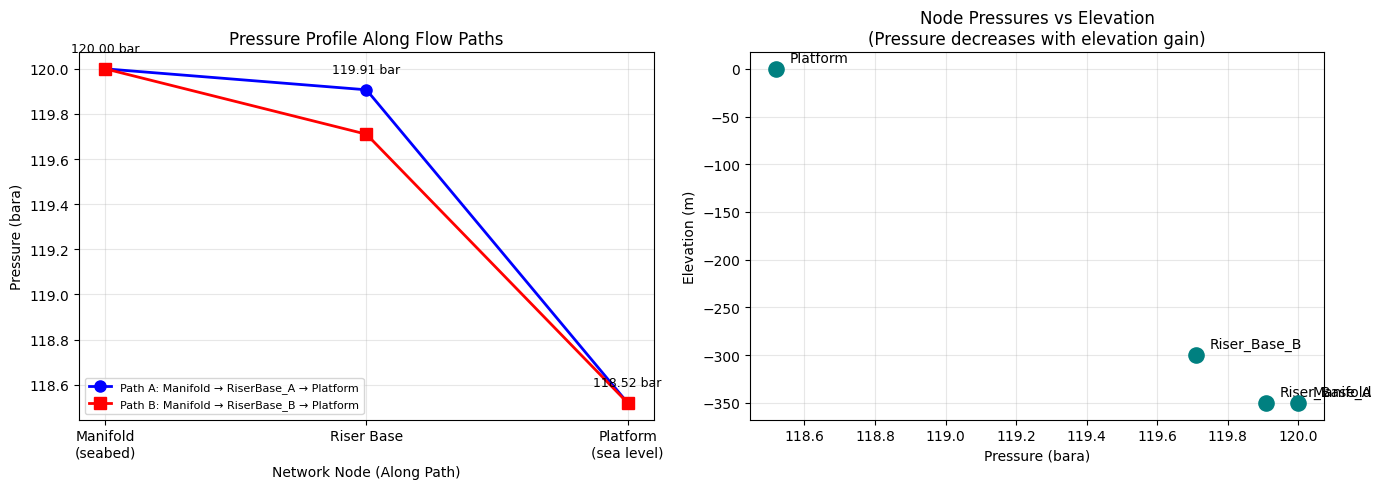

Figure saved: figures/offshore_gathering_network.png


In [9]:
# Visualize the offshore network
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pressure profile through two paths
path_A = ["Manifold", "Riser_Base_A", "Platform"]
elev_A = [-350.0, -350.0, 0.0]
press_A = [net3.getNodePressure(n) for n in path_A]

path_B = ["Manifold", "Riser_Base_B", "Platform"]
elev_B = [-350.0, -300.0, 0.0]
press_B = [net3.getNodePressure(n) for n in path_B]

axes[0].plot(range(3), press_A, 'bo-', linewidth=2, markersize=8,
             label='Path A: Manifold → RiserBase_A → Platform')
axes[0].plot(range(3), press_B, 'rs-', linewidth=2, markersize=8,
             label='Path B: Manifold → RiserBase_B → Platform')
for i, node in enumerate(path_A):
    axes[0].annotate(f'{press_A[i]:.2f} bar',
                     (i, press_A[i]), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)

axes[0].set_xlabel('Network Node (Along Path)')
axes[0].set_ylabel('Pressure (bara)')
axes[0].set_title('Pressure Profile Along Flow Paths')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Manifold\n(seabed)', 'Riser Base', 'Platform\n(sea level)'])
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Elevation vs pressure scatter
all_nodes = ["Manifold", "Riser_Base_A", "Riser_Base_B", "Platform"]
all_elev = [-350.0, -350.0, -300.0, 0.0]
all_press = [net3.getNodePressure(n) for n in all_nodes]

axes[1].scatter(all_press, all_elev, s=120, c='teal', zorder=5)
for i, name in enumerate(all_nodes):
    axes[1].annotate(name, (all_press[i], all_elev[i]),
                     textcoords='offset points', xytext=(10, 5), fontsize=10)

axes[1].set_xlabel('Pressure (bara)')
axes[1].set_ylabel('Elevation (m)')
axes[1].set_title('Node Pressures vs Elevation\n(Pressure decreases with elevation gain)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'offshore_gathering_network.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/offshore_gathering_network.png")

### Discussion — Example 3

The offshore network shows how elevation changes affect pressure distribution.
Wells at depth have higher pressures, and the risers to the platform involve a
significant hydrostatic head contribution. The ring connection between manifolds
provides redundancy and helps balance flow from the two wells.

## Example 4: Sensitivity Study — Pipe Diameter Impact

Investigate how pipe diameter affects pressure drop and flow distribution
in a simple network. This is a typical pipeline sizing exercise.

In [10]:
# Sensitivity: vary main pipe diameter
diameters = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
pressure_drops = []
velocities = []

for d in diameters:
    net_s = LoopedPipeNetwork(f"sensitivity_D{d}")
    net_s.setFluidTemplate(gas)
    net_s.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net_s.setMaxIterations(50)
    net_s.setTolerance(100.0)

    net_s.addSourceNode("S", 60.0, 5000.0)
    net_s.addSinkNode("D", 5000.0)
    net_s.addPipe("S", "D", "main", 10000.0, d)  # 10 km pipeline

    net_s.run()

    if net_s.isConverged():
        dp = net_s.getNodePressure("S") - net_s.getNodePressure("D")
        v = net_s.getPipeVelocity("main")
        pressure_drops.append(dp)
        velocities.append(v)
        print(f"D={d:.2f}m: ΔP={dp:.3f} bar, v={v:.2f} m/s")
    else:
        pressure_drops.append(float('nan'))
        velocities.append(float('nan'))
        print(f"D={d:.2f}m: DID NOT CONVERGE")

print(f"\nTotal cases: {len(diameters)}")

D=0.15m: ΔP=0.805 bar, v=1.95 m/s
D=0.20m: ΔP=0.185 bar, v=1.09 m/s
D=0.25m: ΔP=0.060 bar, v=0.70 m/s
D=0.30m: ΔP=0.024 bar, v=0.49 m/s
D=0.35m: ΔP=0.011 bar, v=0.36 m/s
D=0.40m: ΔP=0.006 bar, v=0.27 m/s
D=0.50m: ΔP=0.002 bar, v=0.18 m/s

Total cases: 7


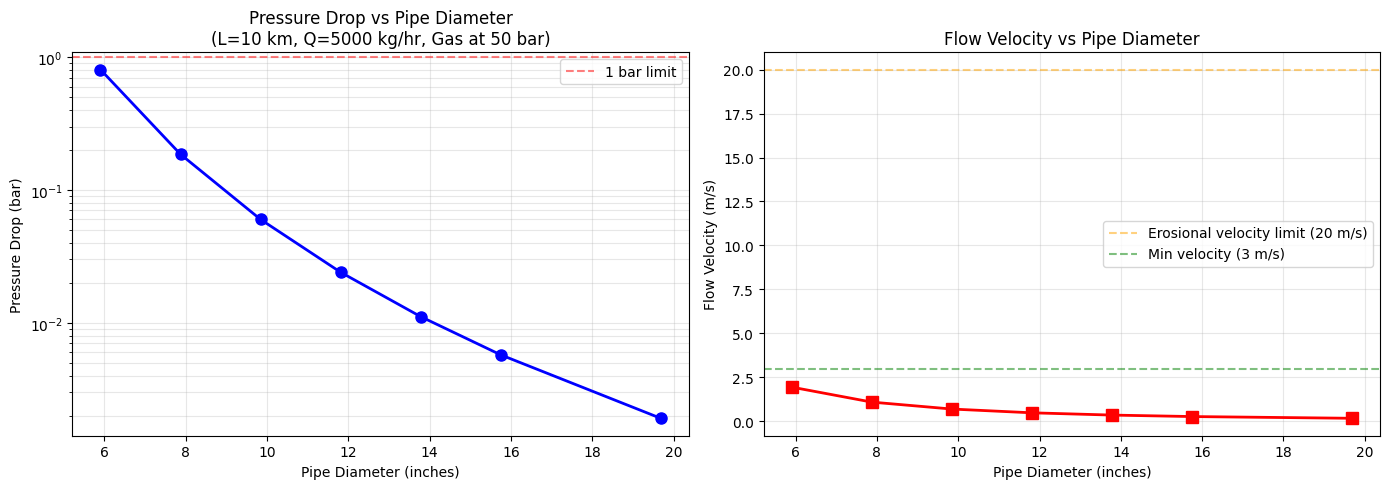

Figure saved: figures/diameter_sensitivity.png


In [11]:
# Plot diameter sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d_inches = [d * 39.37 for d in diameters]  # Convert to inches for labeling

# Pressure drop vs diameter
axes[0].semilogy(d_inches, pressure_drops, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Pipe Diameter (inches)')
axes[0].set_ylabel('Pressure Drop (bar)')
axes[0].set_title('Pressure Drop vs Pipe Diameter\n(L=10 km, Q=5000 kg/hr, Gas at 50 bar)')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='1 bar limit')
axes[0].legend()

# Velocity vs diameter
axes[1].plot(d_inches, velocities, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Pipe Diameter (inches)')
axes[1].set_ylabel('Flow Velocity (m/s)')
axes[1].set_title('Flow Velocity vs Pipe Diameter')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=20.0, color='orange', linestyle='--', alpha=0.5, label='Erosional velocity limit (20 m/s)')
axes[1].axhline(y=3.0, color='green', linestyle='--', alpha=0.5, label='Min velocity (3 m/s)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'diameter_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/diameter_sensitivity.png")

### Discussion — Example 4

Pressure drop decreases dramatically with increasing diameter (roughly proportional
to $D^{-5}$ for fully turbulent Darcy-Weisbach flow). The erosional velocity limit
(typically 20 m/s for gas pipelines per API RP 14E) constrains the minimum pipe size,
while minimum velocity requirements (to prevent liquid accumulation in wet gas lines)
constrain the maximum pipe size.

## Example 5: JSON Output and Hydraulic Report

The network produces a comprehensive JSON report with all hydraulic parameters,
suitable for automated processing and integration with engineering tools.

In [12]:
# Build a small network and get JSON report
net5 = LoopedPipeNetwork("JSON Report Demo")
net5.setFluidTemplate(gas)
net5.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net5.setMaxIterations(50)
net5.setTolerance(100.0)

net5.addSourceNode("Supply", 55.0, 3000.0)
net5.addJunctionNode("J1")
net5.addSinkNode("Cust_A", 1800.0)
net5.addSinkNode("Cust_B", 1200.0)

net5.addPipe("Supply", "J1", "header", 2000.0, 0.4)
net5.addPipe("J1", "Cust_A", "branch_A", 1500.0, 0.25)
net5.addPipe("J1", "Cust_B", "branch_B", 1000.0, 0.2)

net5.run()

# Get and parse JSON
json_str = net5.toJson()
report = json.loads(str(json_str))

# Display formatted
print(json.dumps(report, indent=2))

{
  "name": "JSON Report Demo",
  "numberOfNodes": 4,
  "numberOfPipes": 3,
  "numberOfLoops": 0,
  "solverType": "NEWTON_RAPHSON",
  "converged": true,
  "iterations": 2,
  "maxResidual_Pa": 9.930944955272025e-09,
  "nodes": [
    {
      "name": "J1",
      "type": "JUNCTION",
      "pressure_bara": 54.99955653502957,
      "demand_kghr": 0.0,
      "temperature_K": 288.15,
      "elevation_m": 0.0
    },
    {
      "name": "Supply",
      "type": "SOURCE",
      "pressure_bara": 55.0,
      "demand_kghr": -3000.0,
      "temperature_K": 288.15,
      "elevation_m": 0.0
    },
    {
      "name": "Cust_B",
      "type": "SINK",
      "pressure_bara": 54.99832796282368,
      "demand_kghr": 1200.0,
      "temperature_K": 288.15,
      "elevation_m": 0.0
    },
    {
      "name": "Cust_A",
      "type": "SINK",
      "pressure_bara": 54.99825389768969,
      "demand_kghr": 1800.0,
      "temperature_K": 288.15,
      "elevation_m": 0.0
    }
  ],
  "pipes": [
    {
      "name": "bra

## Example 6: Pressure-Pressure Mode (Deliverability Calculation)

Instead of specifying flow rates, set **fixed pressures** at both the inlet (source) and
outlet (sink). The solver computes the flow rate that the network can deliver — this is
the same "deliverability" or "nodal analysis" concept used in PIPESIM and production engineering.

Use `addFixedPressureSinkNode(name, pressureBar)` for the delivery point.
Use `getNodeFlowRate(name)` to read the computed delivered flow.

In [4]:
# Example 6a: Single pipe deliverability — what flow can a 10 km, 12-inch pipe deliver
# from 80 bar source to 75 bar delivery point?

net6 = LoopedPipeNetwork("Deliverability Demo")
net6.setFluidTemplate(gas)
net6.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
net6.setMaxIterations(100)
net6.setTolerance(100.0)

# Fixed-pressure source and sink — flow rate determined by solver
net6.addSourceNode("Wellhead", 80.0, 0.0)        # 80 bara
net6.addFixedPressureSinkNode("Platform", 75.0)    # 75 bara delivery

net6.addPipe("Wellhead", "Platform", "export", 10000.0, 0.30)  # 10 km, 12-inch

net6.run()

delivered = net6.getNodeFlowRate("Platform")
pipe_flow = net6.getPipeFlowRate("export")

print(f"Converged: {net6.isConverged()}, Iterations: {net6.getIterationCount()}")
print(f"\nPressure-Pressure Mode Results:")
print(f"  Source pressure:   {net6.getNodePressure('Wellhead'):.2f} bara")
print(f"  Delivery pressure: {net6.getNodePressure('Platform'):.2f} bara")
print(f"  Pressure drop:     {net6.getNodePressure('Wellhead') - net6.getNodePressure('Platform'):.2f} bar")
print(f"  Delivered flow:    {delivered:.0f} kg/hr")
print(f"  Pipe velocity:     {net6.getPipeVelocity('export'):.2f} m/s")
print(f"  Reynolds number:   {net6.getPipeReynoldsNumber('export'):.0f}")
print(f"  Friction factor:   {net6.getPipeFrictionFactor('export'):.6f}")

Converged: True, Iterations: 4

Pressure-Pressure Mode Results:
  Source pressure:   80.00 bara
  Delivery pressure: 75.00 bara
  Pressure drop:     5.00 bar
  Delivered flow:    77117 kg/hr
  Pipe velocity:     7.51 m/s
  Reynolds number:   7434171
  Friction factor:   0.013190


P_delivery=60 bar, ΔP=20 bar: flow=154854 kg/hr, v=15.07 m/s
P_delivery=65 bar, ΔP=15 bar: flow=134021 kg/hr, v=13.04 m/s
P_delivery=70 bar, ΔP=10 bar: flow=109311 kg/hr, v=10.64 m/s
P_delivery=72 bar, ΔP=8 bar: flow=97706 kg/hr, v=9.51 m/s
P_delivery=74 bar, ΔP=6 bar: flow=84534 kg/hr, v=8.23 m/s
P_delivery=75 bar, ΔP=5 bar: flow=77117 kg/hr, v=7.51 m/s
P_delivery=76 bar, ΔP=4 bar: flow=68914 kg/hr, v=6.71 m/s
P_delivery=78 bar, ΔP=2 bar: flow=48565 kg/hr, v=4.73 m/s


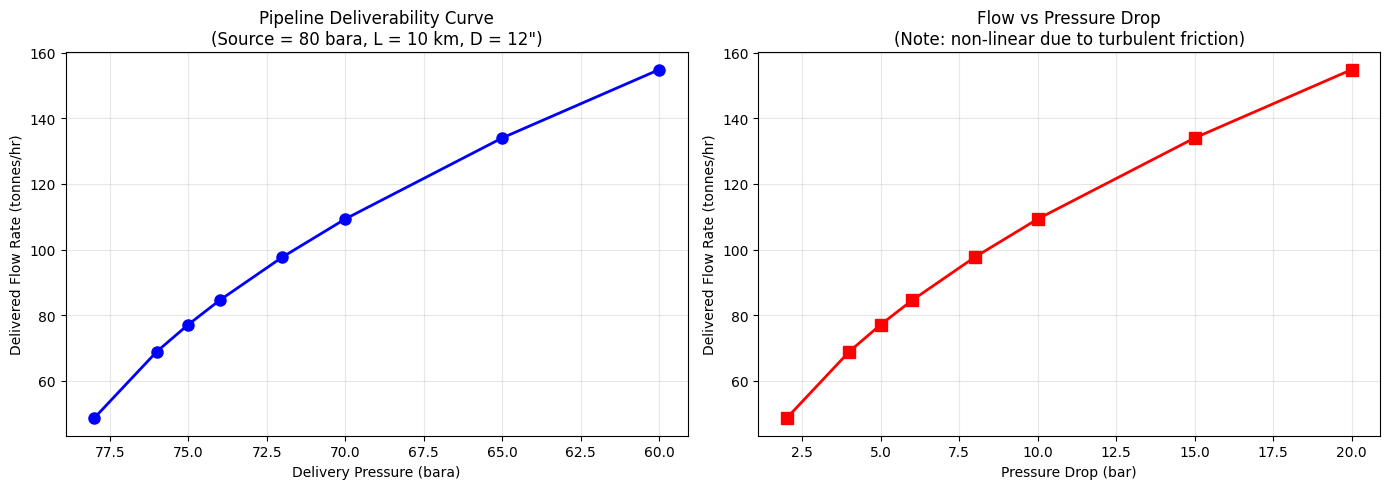

Figure saved: figures/pipeline_deliverability.png


In [6]:
import os

# Example 6b: Deliverability sensitivity — how does delivery pressure affect flow?
delivery_pressures = [60.0, 65.0, 70.0, 72.0, 74.0, 75.0, 76.0, 78.0]
flows = []
velocities_pp = []

for p_del in delivery_pressures:
    net_pp = LoopedPipeNetwork(f"PP_{p_del}")
    net_pp.setFluidTemplate(gas)
    net_pp.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
    net_pp.setMaxIterations(100)
    net_pp.setTolerance(100.0)

    net_pp.addSourceNode("S", 80.0, 0.0)
    net_pp.addFixedPressureSinkNode("D", p_del)
    net_pp.addPipe("S", "D", "main", 10000.0, 0.30)

    net_pp.run()

    if net_pp.isConverged():
        flow = net_pp.getNodeFlowRate("D")
        vel = net_pp.getPipeVelocity("main")
        flows.append(flow)
        velocities_pp.append(vel)
        dp = 80.0 - p_del
        print(f"P_delivery={p_del:.0f} bar, ΔP={dp:.0f} bar: flow={flow:.0f} kg/hr, v={vel:.2f} m/s")
    else:
        flows.append(float('nan'))
        velocities_pp.append(float('nan'))

# Plot: Deliverability curve (IPR-like)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(delivery_pressures, [f/1000 for f in flows], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Delivery Pressure (bara)')
axes[0].set_ylabel('Delivered Flow Rate (tonnes/hr)')
axes[0].set_title('Pipeline Deliverability Curve\n(Source = 80 bara, L = 10 km, D = 12")')
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()  # Higher ΔP = more flow on left

dp_values = [80.0 - p for p in delivery_pressures]
axes[1].plot(dp_values, [f/1000 for f in flows], 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Pressure Drop (bar)')
axes[1].set_ylabel('Delivered Flow Rate (tonnes/hr)')
axes[1].set_title('Flow vs Pressure Drop\n(Note: non-linear due to turbulent friction)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'examples', 'notebooks', 'figures')
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(os.path.join(fig_dir, 'pipeline_deliverability.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: figures/pipeline_deliverability.png")

### Discussion — Example 6

The **pressure-pressure mode** (`addFixedPressureSinkNode`) lets you specify inlet and outlet
pressures and have the solver compute the corresponding flow rate. This is the same concept as:

- **PIPESIM**: "Fixed outlet pressure" boundary condition
- **Production engineering**: Inflow Performance Relationship (IPR) / Vertical Lift Performance (VLP)
  intersection (nodal analysis)
- **EPANET**: Reservoirs with fixed head at both ends

The deliverability curve shows the nonlinear relationship $Q \propto \sqrt{\Delta P}$ characteristic
of turbulent pipe flow.  As the delivery pressure approaches the source pressure, the available
driving force decreases and flow drops toward zero.

**Use cases**: Pipeline capacity assessment, backpressure sensitivity, export pipeline sizing,
gas sales contract deliverability verification.

## Summary

The `LoopedPipeNetwork` class provides a PIPESIM-Network-level capability for solving
steady-state flow distribution in looped gas pipeline networks:

| Feature | NeqSim LoopedPipeNetwork | PIPESIM Network |
|---------|--------------------------|------------------|
| Solver algorithms | Hardy Cross + Newton-Raphson GGA | Newton-Raphson |
| Friction model | Darcy-Weisbach (Swamee-Jain) | Darcy-Weisbach / Moody |
| Fluid properties | SRK/PR EOS (real gas) | Black oil / compositional |
| Elevation | Full hydrostatic head | Full hydrostatic head |
| Loop detection | DFS spanning tree (automatic) | Automatic |
| **Boundary conditions** | **Fixed flow OR fixed pressure at any node** | Fixed flow / fixed pressure |
| Output | JSON + text summary | GUI + reports |
| API | Java + Python (via jneqsim) | GUI + scripting |

### Operating Modes
- **Demand mode** (`addSinkNode`): Specify flow demands, solver finds pressures
- **Pressure-pressure mode** (`addFixedPressureSinkNode`): Specify inlet/outlet pressures, solver finds flow rates (deliverability)

### Next Steps
- **Compressor/pump stations**: Add boosting equipment at nodes
- **Beggs & Brill**: Enable two-phase flow in individual pipes
- **Time-varying demand**: Dynamic network simulation
- **Network optimization**: Minimize compression power or maximize throughput